# 巻き積分ニューラルネットワーク（CNN）による数字識別システム


- ソースコード倉庫
https://github.com/morookaatsuhiro/number-recognition-system

- PCモデルを訓練するシステムウェブサイト画面
https://number-recognition-system.vercel.app/login.html

- 識別画面
https://number-recognition-system.vercel.app/phone.html




---
## 一、自己紹介

**1.氏名 / 専攻・専門背景**　　
<p>
師岡淳博／コンピューターサイエンス


**2.研究分野またはキャリア上の立ち位置**　　

主に自然言語処理分野を学びました

**3.なぜ CNN を本研究・本プロジェクトの主題にしたか**　　

数字認識というシンプルなプロジェクトでしたが、私がAIに本格的に興味を持つきっかけになりました。自分で調べながら開発する中で、AIの奥深さと自分の無知さを知り、自然言語処理や先端技術をもっと学びたい、もっと触れたいと思うようになりました。


</p>


![个人照片](.\images\photo3.jpg)
![学位](.\images\学位证书.png)
![毕业证](.\images\毕业证书.png)

---


https://www.bilibili.com/video/BV1gz67YrE7H?t=11.5


<iframe width="1024" height="768" src="https://www.bilibili.com/video/BV1gz67YrE7H?t=0.8" 
  title="bilibili" frameborder="0" allowfullscreen></iframe>


![视频中的识别流程结构图](https://i-blog.csdnimg.cn/blog_migrate/f4363cdf1c33d40962da3c5c20c15bca.png)

---

## 二、CNN アルゴリズムの解説

### 2.1 CNN の概要
- 巻き積分ニューラルネットワークとは何か　　
<p>
画像を認識するディープラーニング（深層学習）の一種で、人の視覚を模倣し、局所的な特徴（エッジや模様）を自動抽出して物体や顔を識別するAI技術です。
</p>

- 人間が意識で物を認知する流れ図  

![认知的流程](.\images\物体识别流程.png)

cnnモデルの入力画像から特徴抽出までの全体フロー図
<p>

![CNN全体フロー図](https://kenyu-life.com/wp-content/uploads/2019/03/%E3%82%B9%E3%82%AF%E3%83%AA%E3%83%BC%E3%83%B3%E3%82%B7%E3%83%A7%E3%83%83%E3%83%88-2019-03-07-8.56.07.jpg)
</p>

---

### 2.2 CNN の主要構成

<p>
- **畳み込み層：** カーネルが縁・テクスチャ等の局所特徴を抽出

![畳み込み層](https://kenyu-life.com/wp-content/uploads/2019/03/CNN_1.jpg)
![畳み込み層動画](https://kenyu-life.com/wp-content/uploads/2019/03/cnn.gif)


- 畳み込み直後の特徴マップ例


![畳み込み後の効果図](https://i-blog.csdnimg.cn/blog_migrate/e33c53db9579a9b6b79aecd909f2faef.png)

</p>


---
<p>
- **プーリング層：** 
最大プーリング／平均プーリング、パラメター行列つまりデータ量の次元削減と一定の移動不変性の模擬</p>


![プーリング層](https://kenyu-life.com/wp-content/uploads/2019/03/CNN_2.jpg)
![プーリング層動画](https://kenyu-life.com/wp-content/uploads/2019/03/pooling.gif)


- プーリングした後の効果図


![プーリングした後の効果図](https://i-blog.csdnimg.cn/blog_migrate/5350f7134f48449101c2f12a0db03e08.png)

</p>




---




- **活性化層（例：ReLU、Sigmoid、Softmax関数など）：** 
  <p>この層があるおかげで、AIは「ただの数値の羅列」から「画像の意味」を理解できるようになります。ニューラルネットワークの本質は行列演算にあります。もし活性化関数がなければ、何層重ねたとしても、最終的には線形変換の累積に過ぎず、現実世界の複雑な非線形データを処理することはできません。</p>













1.Sigmoid関数

<p>

![Sigmoid関数処理](.\images\sigmoid.png)
</p>

---

<p>


2.Softmax関数

![Softmax関数处理](.\images\softmax.png)

</p>

---

<p>


3.ReLU関数


![ReLU関数处理](.\images\relu层.png)



</p>

---

<p>


- **全結合層：** 特徴を集約しクラスを出力


![全結合層](https://kenyu-life.com/wp-content/uploads/2019/03/CNN_3.jpg)


![全結合層動画](https://kenyu-life.com/wp-content/uploads/2019/03/flatting.jpg)


</p>

---

### 2.3 CNN の応用分野

<p>


- 画像分類、顔認識


![顔認識](https://amnimo.com/wp-content/uploads/2023/03/02.jpg)



- 物体検出、自動運転の知覚


![自動運転の知覚](https://staff.persol-xtech.co.jp/i-engineer/wp-content/uploads/2021/09/stradvision_760.jpg)


- 医用画像、スタイル変換 など


![癌细胞识别](https://img.toto.im/mw1024/00745YaMgy1hzeim2rum8j30vz0nr195.jpg)

</p>

## 三、プロジェクトデータベースの紹介（手書き数字認識）

### 3.1 データセットMNIST




In [3]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

# 中文标题、坐标轴：默认 DejaVu Sans 没有汉字字形，会显示成「□□」方框
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "SimSun",
    "Noto Sans CJK SC",
    "PingFang SC",
    "Heiti TC",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False  # 用 ASCII 减号，避免负号变成方框

# 与展示「原始像素样式」一致：仅转张量，不做随机增强
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST(root=str(MNIST_ROOT), train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root=str(MNIST_ROOT), train=False, download=True, transform=transform)

print(f"训练集样本数: {len(train_ds):,}")
print(f"测试集样本数: {len(test_ds):,}")
x0, y0 = train_ds[0]
print(f"单样本张量形状: {tuple(x0.shape)}（C×H×W，MNIST 为 1×28×28）")
print(f"像素取值（归一化后）约落在: [{x0.min().item():.3f}, {x0.max().item():.3f}]")
print(f"标签类型: int，示例标签: {y0}")

训练集样本数: 60,000
测试集样本数: 10,000
单样本张量形状: (1, 28, 28)（C×H×W，MNIST 为 1×28×28）
像素取值（归一化后）约落在: [-0.424, 2.821]
标签类型: int，示例标签: 5


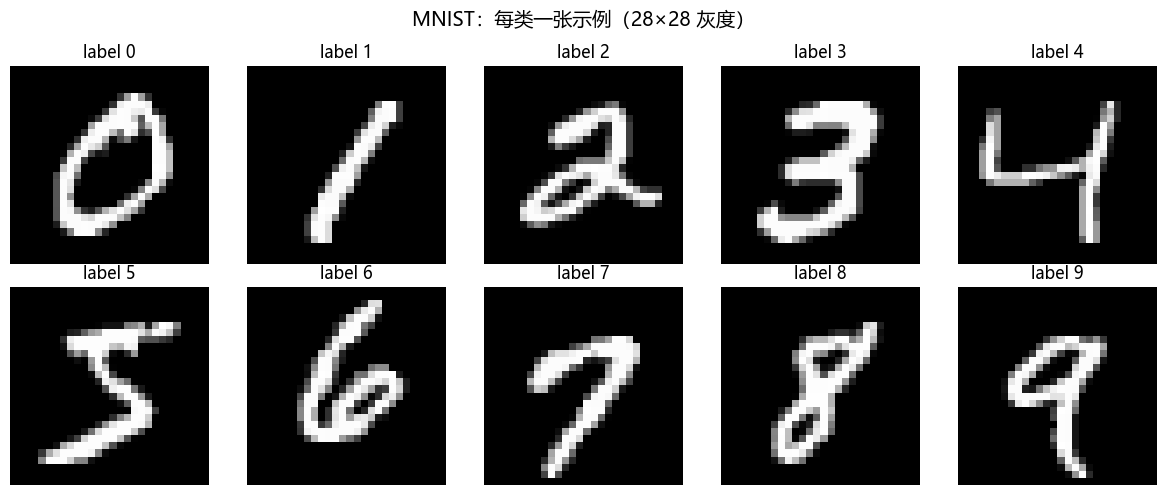

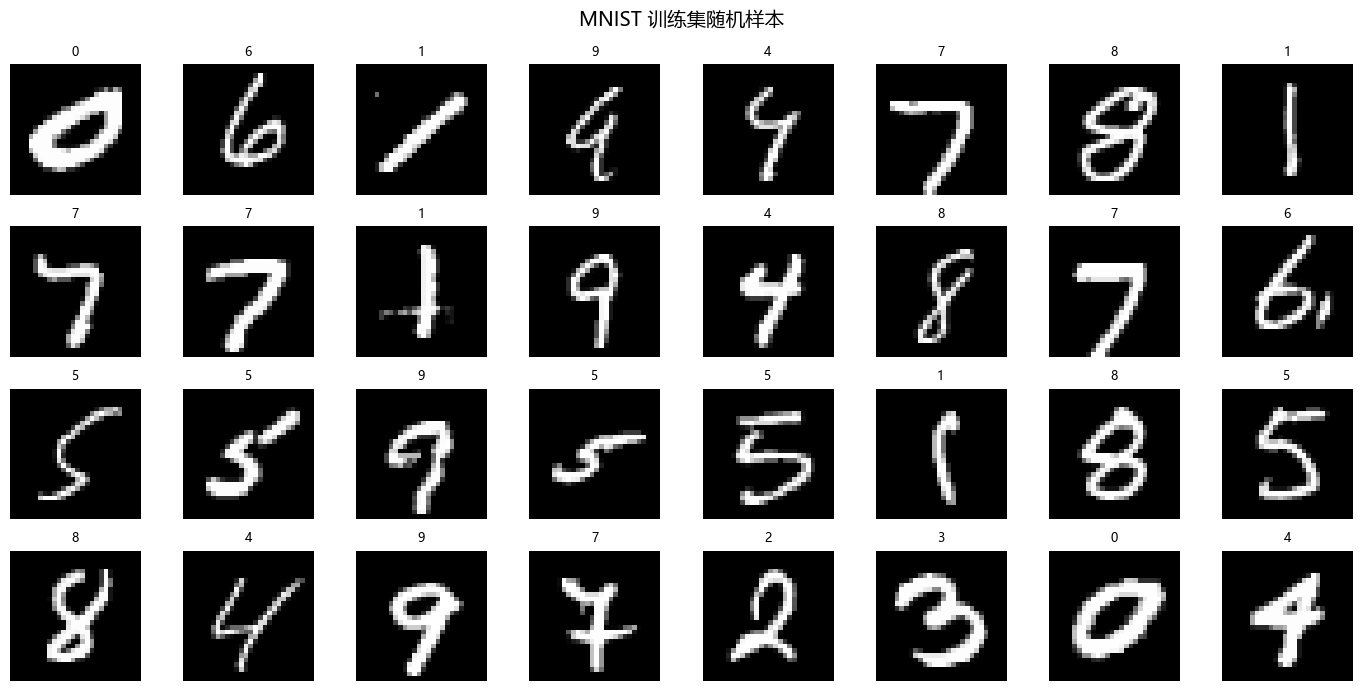

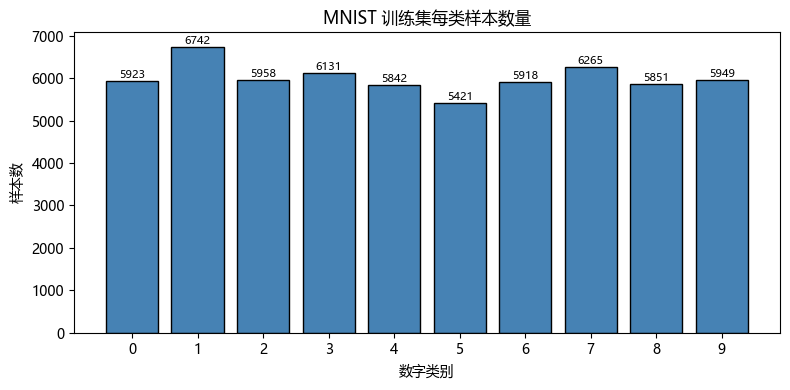

In [7]:
def tensor_to_display_gray(img_tensor):
    """反归一化到 [0,1] 便于 imshow。"""
    t = img_tensor.clone().squeeze(0).numpy()
    t = t * 0.3081 + 0.1307
    return np.clip(t, 0.0, 1.0)


fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
found = {d: None for d in range(10)}
for idx in range(len(train_ds)):
    img, label = train_ds[idx]
    if found[label] is None:
        found[label] = img
    if all(v is not None for v in found.values()):
        break

for d in range(10):
    ax = axes[d]
    ax.imshow(tensor_to_display_gray(found[d]), cmap="gray")
    ax.set_title(f"label {d}")
    ax.axis("off")
plt.suptitle("MNIST：每类一张示例（28×28 灰度）", fontsize=14)
plt.tight_layout()
plt.show()
rng = np.random.default_rng(42)
n_rows, n_cols = 4, 8
indices = rng.choice(len(train_ds), size=n_rows * n_cols, replace=False)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7))
for ax, i in zip(axes.flatten(), indices):
    img, label = train_ds[i]
    ax.imshow(tensor_to_display_gray(img), cmap="gray")
    ax.set_title(str(label), fontsize=9)
    ax.axis("off")
plt.suptitle("MNIST 训练集随机样本", fontsize=14)
plt.tight_layout()
plt.show()
from collections import Counter

labels = [train_ds[i][1] for i in range(len(train_ds))]
cnt = Counter(labels)
digits = sorted(cnt.keys())
counts = [cnt[d] for d in digits]

plt.figure(figsize=(8, 4))
plt.bar(digits, counts, color="steelblue", edgecolor="black")
plt.xticks(digits)
plt.xlabel("数字类别")
plt.ylabel("样本数")
plt.title("MNIST 训练集每类样本数量")
for d, c in zip(digits, counts):
    plt.text(d, c, str(c), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

---
## 四、困難と解决

<p>


### 4.1 代表例：問題と対策（必要に応じて抜粋）
- 1.手書き数字の写真の予備処理するときに、写真の識別が、paddingすることによって、予備処理された写真がもっと訓練するデータベースの写真と一致するようになる　　


　　　　　　　　　　　　　　![1识别](.\images\re1.png)　　　　　　　　　　　　　　![1识别](.\images\reco1.png)

- 2.データベースの分類数が0-9の10個しかありませんので、訓練する時、本当に学ぶ前に先に訓練データで過学習してしまう → 色んな論文を見て、Dropout層を入れる。

- 3.勾配の問題 / 感度の高いハイパーパラ → 学習率、モメンタム、層の深さ・幅が決まったわけではなく、最初にどうしても訓練できなく、色んな論文を見ながら、学習して自分の計算資源が足りない原因で作動しないことが発覚しました。

- 4.実装面 → デプロイ、モデルパス、メモリ、CORS 等
バックエンドとフロントエンドが分離するプロジェクトなので、配置はvercelでフロントエンドとrailwayバックエンドを配置しましたが、データ伝送に権限の問題が分かりづらい所もありました。何回、何十回もデバッグをしながら、ようやく権限が通り、データの伝送できるようになりました。


</p>



---

### 4.2 まとめと展望

このプロジェクトを通じて、**最前端AI技術の底層に一歩近づいた**実感があります。

#### 1.理論面
- 畳み込みによる**局所結合**と**重み共有**が、なぜ画像の局所パターンを効率よく学べるのかを、式だけでなく「情報の流れ」として掴めました。
- プーリングや活性化、全結合まで含め、**特徴が段階的に抽象化される**イメージがつながりました。これは後の RNN や注意力規制、self-attentionを読むときの土台になりました。

#### 2.実装面
- ハイパーパラメータの調整、学習ログの読み方、**バックエンドと Python プロセスの連携**など、教科書に載りにくい部分に触れました。
- デプロイ時の CORS・セッション・モデルファイル・メモリなど、**症状を切り分ける**経験が、単に API を叩くだけでは得にくい理解につながった。

---

#### このプロジェクトを通じて得た、エンジニアとしての成長への展望
- CNN を**視覚の入り口**として押さえたうえで、より複雑なタスクへ広げたい。AIをただ「黒箱」で使うだけではなく、**データ・損失・勾配・計算資源**まで意識できるようになることが、今後の私の学習目標です。

今後は単なるエンジニアではなく、最前端AI技術を使いこなせるようなweb4.0のエンジニアに成長して行きたいと私は思います。



------

# CNNニューラルネットワークのメインコード

In [ ]:

#卷积神经网络cnn核心算法
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # 说明：创建第一个卷积层模块 conv1，包括一个卷积操作、一个 ReLU 激活函数和一个池化操作。
        self.conv1 = torch.nn.Sequential(
            # 1：输入通道数。表示输入的是单通道图像（如灰度图像，通常用于 MNIST 数据集），每张图片的输入尺寸为 (batch_size, 1, 28, 28)。
            # 10：输出通道数，表示经过卷积后得到 10 个特征图。
            # kernel_size=5：卷积核的大小为 5x5。
            torch.nn.Conv2d(in_channels=conv2dinchannels, out_channels=conv2doutchannels, kernel_size=conv2dkernel_size , padding = conv2dpadding , stride = convstride),
            # torch.nn.ReLU()：ReLU 激活函数，将负值置零，正值保持不变。
            torch.nn.ReLU(),
            torch.nn.Dropout(p=0.3),
            # kernel_size=2：池化窗口大小为 2x2，进行最大池化操作，缩小图像尺寸，将每 2x2 的区域压缩为一个最大值。
            torch.nn.MaxPool2d(kernel_size=Pool2dkernel_size)

        )
        #连接上面的输出通道作为第二次卷积的输入接口
        secondconv2doutchannels = conv2doutchannels*2
        self.conv2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=conv2doutchannels, out_channels=secondconv2doutchannels, kernel_size=conv2dkernel_size,padding = conv2dpadding , stride = convstride),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=0.3),
            torch.nn.MaxPool2d(kernel_size=Pool2dkernel_size)

        )
        # 说明：创建全连接层 fc，由两层线性变换组成。
        self.fc = torch.nn.Sequential(
            # 320：输入的特征数，来自卷积层的展平输出大小（320 = 20 * 4 * 4，20 是上一层的输出通道数，4x4 是经过池化后的特征图尺寸）。
            # 50：输出的神经元个数，即第一层全连接层的输出维度。
            torch.nn.Linear(secondconv2doutchannels*window*window, secondconv2doutchannels),
            # 50：输入维度来自上一层。
            # 10：输出维度为 10，对应 0~9 的数字分类。
            torch.nn.Linear(secondconv2doutchannels, 10)

        )

    def forward(self, x):
        # 说明：forward 定义了模型的前向传播逻辑。
        # batch_size = x.size(0)：获取输入的批量大小，x.size(0) 返回批量维度的大小。
        batch_size = x.size(0)

        x = self.conv1(x)  # 一层卷积层,一层池化层,一层激活层(图是先卷积后激活再池化，差别不大)
        x = self.conv2(x)  # 再来一次

        # flatten 变成全连接网络需要的输入 (batch, 20,4,4) ==> (batch,320), -1 此处自动算出的是320
        x = x.view(batch_size, -1)

        #传入全连接层
        x = self.fc(x)
        return x  # 最后输出的是维度为10的，也就是（对应数学符号的0~9）
